# Tech Challenge - Fase 1
## Notebook 02 — Storytelling Executivo | E-commerce Olist

Este notebook reúne os principais resultados obtidos durante a análise
exploratória e organiza os achados em uma narrativa executiva.

O objetivo é destacar os indicadores mais relevantes para compreender
o desempenho comercial, a experiência dos clientes e os principais
pontos de atenção relacionados à logística.


## 1. Objetivo do storytelling

### 1.1 Pergunta norteadora

A análise foi iniciada a partir da seguinte pergunta:

**Clientes mais satisfeitos apresentam pedidos de maior valor?**

A investigação mostrou que o valor do pedido apresenta pouca relação
com a satisfação dos clientes.

Por outro lado, o desempenho das entregas apresentou uma associação
consideravelmente mais relevante com as avaliações.

A partir desse resultado, o storytelling será organizado em três questões:

**Como o negócio evoluiu?**

**O que está mais associado à insatisfação dos clientes?**

**Onde as ações de melhoria podem ser priorizadas?**

### 1.2 Premissas de leitura

- **Valor transacionado:** soma do valor dos produtos dos pedidos analisados.
  Não representa receita ou margem da Olist.
- **Avaliação baixa:** notas 1 ou 2 no `review_score`.
- **Pedido atrasado:** pedido cuja entrega ocorreu após a data estimada.
- **Análise temporal principal:** janeiro de 2017 a agosto de 2018.
  Os registros de 2016 foram mantidos na base, mas não utilizados como
  referência principal devido à baixa quantidade de pedidos.


### 1.3 Preparação do ambiente

O notebook utiliza os resultados consolidados no Notebook 01.
Nesta etapa, o foco deixa de ser a exploração dos dados e passa a ser
a comunicação dos principais achados.


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import os

PASTA_GRAFICOS_EXECUTIVOS = (
    '/content/drive/MyDrive/Tech_Challenge_Fase1/graficos_storytelling'
)

os.makedirs(PASTA_GRAFICOS_EXECUTIVOS, exist_ok=True)

In [4]:
PASTA_OUTPUTS = '/content/drive/MyDrive/Tech_Challenge_Fase1/outputs'


### 1.4 Carregamento das bases analíticas

São carregadas somente as bases consolidadas necessárias para reconstruir
os indicadores e gráficos utilizados no storytelling.


In [5]:
base_satisfacao_valor = pd.read_csv(
    PASTA_OUTPUTS + '/base_satisfacao_valor.csv'
)

base_entrega_satisfacao = pd.read_csv(
    PASTA_OUTPUTS + '/base_entrega_satisfacao.csv'
)

resumo_estado = pd.read_csv(
    PASTA_OUTPUTS + '/resumo_estado.csv'
)

resumo_seller = pd.read_csv(
    PASTA_OUTPUTS + '/resumo_seller.csv'
)

sellers_atencao = pd.read_csv(
    PASTA_OUTPUTS + '/sellers_atencao.csv'
)

evolucao_comercial = pd.read_csv(
    PASTA_OUTPUTS + '/evolucao_comercial.csv'
)

In [6]:
print('Satisfação x valor:', base_satisfacao_valor.shape)
print('Entrega x satisfação:', base_entrega_satisfacao.shape)
print('Estados:', resumo_estado.shape)
print('Sellers:', resumo_seller.shape)
print('Sellers de atenção:', sellers_atencao.shape)
print('Evolução comercial:', evolucao_comercial.shape)

Satisfação x valor: (95307, 3)
Entrega x satisfação: (95299, 4)
Estados: (27, 7)
Sellers: (738, 5)
Sellers de atenção: (22, 5)
Evolução comercial: (20, 3)


## 2. Crescimento do negócio

Antes de analisar a experiência dos clientes, é importante entender
como a operação evoluiu ao longo do período analisado.

A leitura começa pela quantidade mensal de pedidos entregues e pelo
valor transacionado em produtos.

### 2.1 Evolução dos pedidos

In [7]:
evolucao_comercial['periodo'] = pd.to_datetime(
    evolucao_comercial['periodo']
)

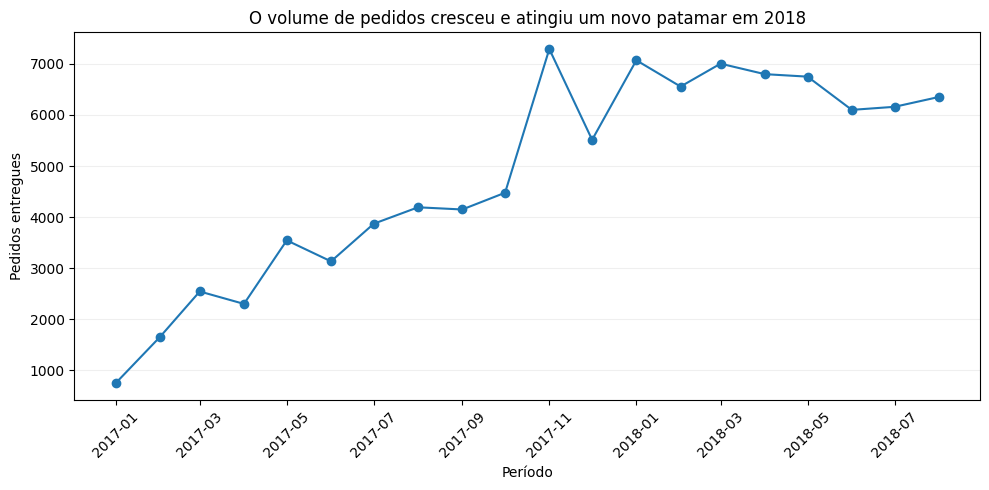

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    evolucao_comercial['periodo'],
    evolucao_comercial['quantidade_pedidos'],
    marker='o'
)

plt.title('O volume de pedidos cresceu e atingiu um novo patamar em 2018')
plt.xlabel('Período')
plt.ylabel('Pedidos entregues')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/01_crescimento_pedidos.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

O volume de pedidos entregues apresentou crescimento expressivo ao longo de 2017.

A quantidade mensal passou de **750 pedidos em janeiro de 2017**
para **7.289 em novembro de 2017**, maior volume observado no período analisado.

Em 2018, mesmo com oscilações mensais, a operação permaneceu em um patamar
superior ao observado no início de 2017, com aproximadamente 6 mil a 7 mil
pedidos entregues por mês.


### 2.2 Evolução do valor transacionado

Além do crescimento da quantidade de pedidos, será analisada a evolução
mensal do valor transacionado em produtos.

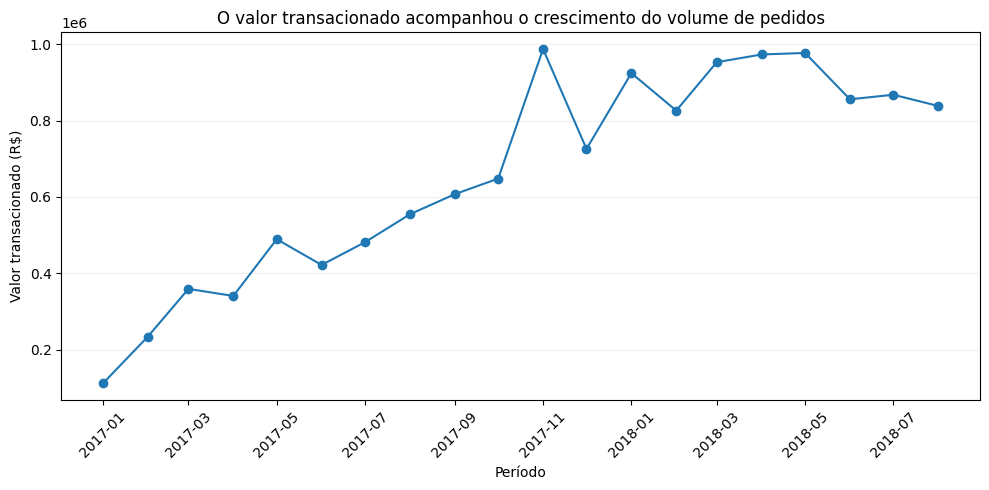

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    evolucao_comercial['periodo'],
    evolucao_comercial['valor_transacionado'],
    marker='o'
)

plt.title('O valor transacionado acompanhou o crescimento do volume de pedidos')
plt.xlabel('Período')
plt.ylabel('Valor transacionado (R$)')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/02_crescimento_valor.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 2.3 Conclusão da evolução comercial

A evolução do valor transacionado acompanhou de perto o crescimento
da quantidade de pedidos.

A correlação de Spearman entre as duas medidas foi de aproximadamente
**0,97**, indicando uma associação positiva muito forte no período analisado.

Como o valor médio por pedido não apresentou tendência contínua de crescimento,
os resultados sugerem que a expansão do valor transacionado esteve mais
relacionada ao aumento do volume de pedidos.


## 3. O que está mais associado à satisfação?

Após compreender a evolução comercial, a análise passa a investigar
a experiência dos clientes.

A pergunta inicial do estudo foi:

**Clientes mais satisfeitos apresentam pedidos de maior valor?**

O primeiro passo é verificar se o valor do pedido apresenta uma relação
relevante com as notas de satisfação.

### 3.1 A hipótese inicial: valor do pedido

O primeiro teste compara o valor mediano dos pedidos entre as diferentes
notas de satisfação.


In [10]:
valor_mediano_por_nota = base_satisfacao_valor.groupby(
    'review_score'
)['price'].median()

valor_mediano_por_nota

,price
review_score,
1,99.00
2,89.90
3,82.92
4,84.18
5,84.99


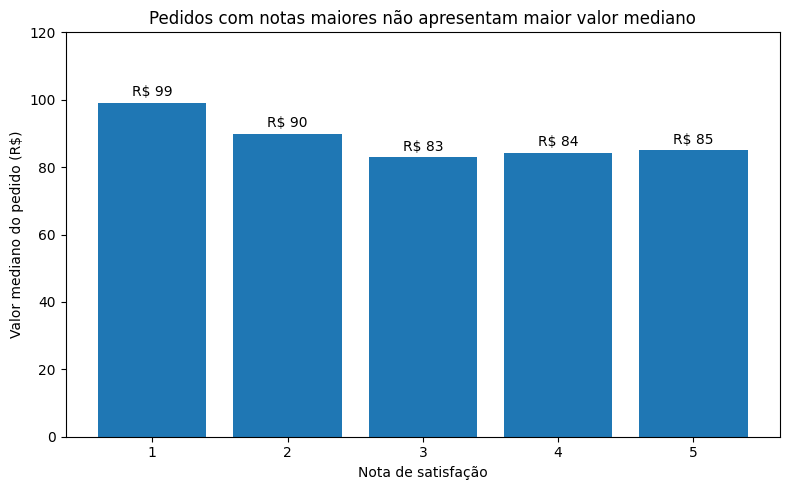

In [11]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    valor_mediano_por_nota.index,
    valor_mediano_por_nota.values
)

plt.title('Pedidos com notas maiores não apresentam maior valor mediano')
plt.xlabel('Nota de satisfação')
plt.ylabel('Valor mediano do pedido (R$)')
plt.ylim(0, 120)

for barra in barras:
    valor = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 2,
        f'R$ {valor:.0f}',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/03_valor_satisfacao.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

O valor mediano dos pedidos não aumenta à medida que a satisfação cresce.

A correlação de Spearman entre a nota de satisfação e o valor do pedido
foi de aproximadamente **-0,03**, indicando ausência de uma associação
relevante entre essas variáveis.

Assim, a hipótese inicial de que pedidos de maior valor estariam associados
a clientes mais satisfeitos não foi sustentada pelos dados.


### 3.2 O principal achado: atraso na entrega

Como o valor do pedido não apresentou associação relevante com a satisfação,
a análise avançou para o desempenho da entrega.

O objetivo agora é comparar a proporção de avaliações baixas entre pedidos
entregues dentro do prazo e pedidos atrasados.

In [12]:
base_entrega_satisfacao['avaliacao_baixa'] = (
    base_entrega_satisfacao['review_score'] <= 2
)

In [13]:
percentual_baixas_entrega = (
    base_entrega_satisfacao
    .groupby('atrasado')['avaliacao_baixa']
    .mean() * 100
)

percentual_baixas_entrega = percentual_baixas_entrega.rename(
    index={
        False: 'Sem atraso',
        True: 'Com atraso'
    }
)

percentual_baixas_entrega

,avaliacao_baixa
atrasado,
Sem atraso,9.249432
Com atraso,62.364237


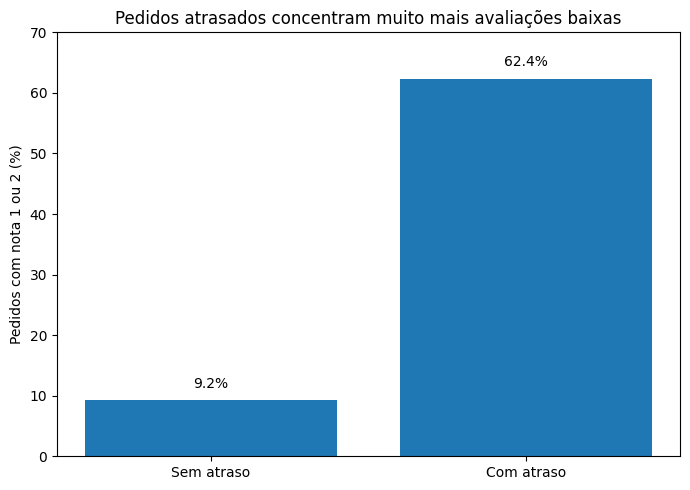

In [14]:
plt.figure(figsize=(7, 5))

barras = plt.bar(
    percentual_baixas_entrega.index,
    percentual_baixas_entrega.values
)

plt.title('Pedidos atrasados concentram muito mais avaliações baixas')
plt.ylabel('Pedidos com nota 1 ou 2 (%)')
plt.ylim(0, 70)

for barra in barras:
    valor = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 2,
        f'{valor:.1f}%',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/04_atraso_satisfacao.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

O atraso na entrega apresentou uma associação muito mais relevante com
a satisfação do que o valor do pedido.

Entre os pedidos entregues sem atraso, aproximadamente **9%** receberam
avaliações com nota 1 ou 2.

Nos pedidos atrasados, esse percentual aumentou para aproximadamente **62%**.

As notas também apresentaram forte diferença entre os dois grupos:
pedidos sem atraso tiveram média de aproximadamente **4,29** e mediana 5,
enquanto pedidos atrasados apresentaram média de aproximadamente **2,27**
e mediana 1.

Esse resultado direcionou a análise para entender se a intensidade do atraso
também está associada à piora da experiência do cliente.

### 3.3 Quanto maior o atraso, pior a experiência?

Após identificar a forte diferença entre pedidos com e sem atraso,
a análise avança para verificar como a satisfação se comporta conforme
a quantidade de dias de atraso aumenta.

In [15]:
pedidos_atrasados = base_entrega_satisfacao[
    base_entrega_satisfacao['atrasado'] == True
].copy()

In [16]:
pedidos_atrasados['faixa_atraso'] = pd.cut(
    pedidos_atrasados['diferenca_entrega_dias'],
    bins=[0, 3, 7, 14, float('inf')],
    labels=['1 a 3 dias', '4 a 7 dias', '8 a 14 dias', '15 dias ou mais']
)

In [17]:
pedidos_atrasados['avaliacao_baixa'] = (
    pedidos_atrasados['review_score'] <= 2
)

In [18]:
percentual_baixas_faixa = (
    pedidos_atrasados
    .groupby('faixa_atraso', observed=False)['avaliacao_baixa']
    .mean() * 100
)

percentual_baixas_faixa

,avaliacao_baixa
faixa_atraso,
1 a 3 dias,32.142857
4 a 7 dias,67.528736
8 a 14 dias,80.277778
15 dias ou mais,78.264151


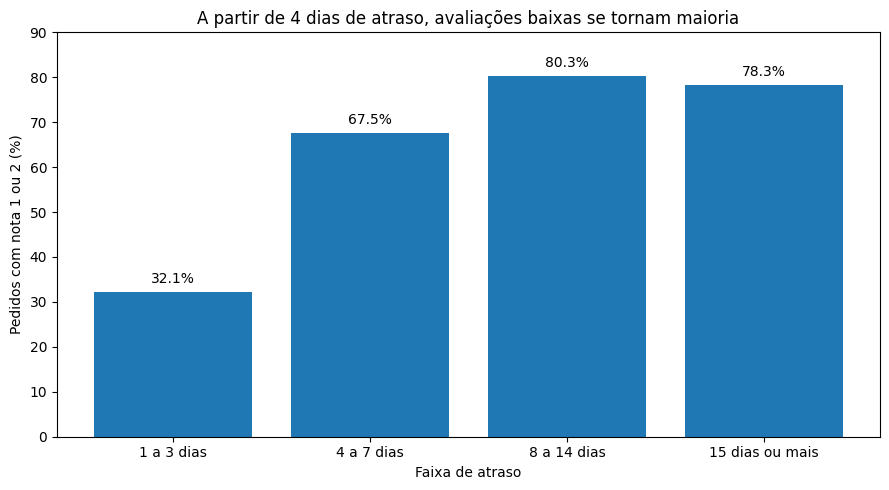

In [19]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    percentual_baixas_faixa.index,
    percentual_baixas_faixa.values
)

plt.title('A partir de 4 dias de atraso, avaliações baixas se tornam maioria')
plt.xlabel('Faixa de atraso')
plt.ylabel('Pedidos com nota 1 ou 2 (%)')
plt.ylim(0, 90)

for barra in barras:
    valor = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 2,
        f'{valor:.1f}%',
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/05_faixa_atraso_satisfacao.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

A proporção de avaliações baixas aumenta de forma expressiva quando
o atraso deixa de ser pequeno.

Nos pedidos com atraso de **1 a 3 dias**, aproximadamente **32%**
receberam notas 1 ou 2.

Entre **4 e 7 dias**, esse percentual sobe para aproximadamente **68%**,
e nos atrasos superiores a 8 dias permanece próximo de **80%**.

A correlação de Spearman entre a quantidade de dias de atraso e a nota
de satisfação foi de aproximadamente **-0,40**, reforçando a associação
entre atrasos maiores e avaliações menores.

Os resultados indicam que o cumprimento do prazo, especialmente a prevenção
de atrasos mais longos, representa um ponto relevante para a experiência
dos clientes.

## 4. Onde priorizar ações?

Os resultados mostram que o atraso na entrega está fortemente associado
à insatisfação dos clientes.

Entretanto, o problema não ocorre com a mesma intensidade em toda a operação.

Para direcionar possíveis ações de melhoria, a análise passa a considerar
duas dimensões:

- diferenças entre os estados;
- desempenho dos sellers.

A priorização deve considerar não apenas taxas de atraso e avaliações baixas,
mas também o volume de pedidos e o valor transacionado.

### 4.1 Priorização por estados

Para evitar conclusões baseadas apenas em percentuais isolados, a análise
considera os estados de maior volume e compara simultaneamente atraso e
avaliações baixas.


In [20]:
estados_maior_volume = resumo_estado.sort_values(
    'quantidade_pedidos',
    ascending=False
).head(10)


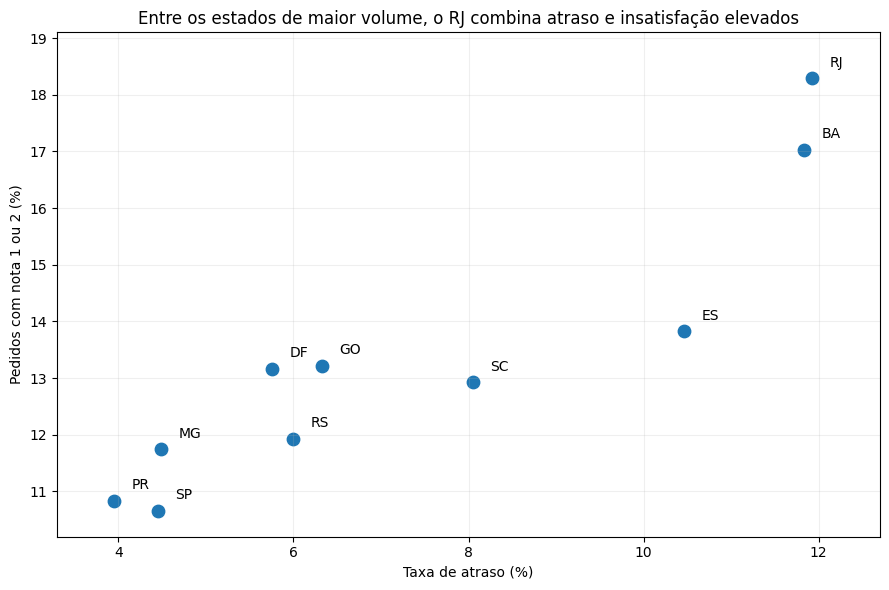

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    estados_maior_volume['taxa_atraso'],
    estados_maior_volume['taxa_avaliacoes_baixas'],
    s=80
)

for _, linha in estados_maior_volume.iterrows():
    plt.text(
        linha['taxa_atraso'] + 0.2,
        linha['taxa_avaliacoes_baixas'] + 0.2,
        linha['customer_state']
    )

plt.title('Entre os estados de maior volume, o RJ combina atraso e insatisfação elevados')
plt.xlabel('Taxa de atraso (%)')
plt.ylabel('Pedidos com nota 1 ou 2 (%)')

plt.grid(alpha=0.2)
plt.xlim(3.3, 12.7)
plt.ylim(10.2, 19.1)
plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/06_priorizacao_estados.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

Entre os estados de maior volume de pedidos, o Rio de Janeiro apresenta
uma combinação relevante de atraso e avaliações baixas.

O estado registrou aproximadamente **11,9% de pedidos atrasados** e
**18,3% de avaliações com notas 1 ou 2**.

Minas Gerais, apesar de apresentar volume de pedidos semelhante ao Rio
de Janeiro, registrou taxas menores: aproximadamente **4,5% de atraso**
e **11,8% de avaliações baixas**.

São Paulo concentra o maior volume da operação, porém apresenta indicadores
relativamente melhores, com aproximadamente **4,5% de atraso** e
**10,7% de avaliações baixas**.

Os resultados reforçam que a priorização não deve considerar apenas o tamanho
da operação, mas a combinação entre volume e indicadores de experiência.

No Rio de Janeiro, aproximadamente **R$ 151 mil em valor transacionado**
estiveram associados a pedidos que apresentaram simultaneamente atraso e
avaliação baixa, representando cerca de **8,7% do valor transacionado no estado**.

Esse resultado reforça o RJ como um ponto relevante para investigação
e priorização operacional no recorte analisado.


### 4.2 Priorização por sellers

A análise utiliza o grupo de sellers de atenção definido no Notebook 01
e destaca aqueles com maior valor transacionado.

A classificação é utilizada como critério de priorização para investigação,
e não como ranking definitivo de desempenho.


In [22]:
top_sellers = sellers_atencao.sort_values(
    'valor_transacionado',
    ascending=False
).head(10).copy()

top_sellers['seller_curto'] = (
    top_sellers['seller_id'].str[:6] + '...'
)

In [23]:
top_sellers = top_sellers.sort_values(
    'valor_transacionado',
    ascending=True
)

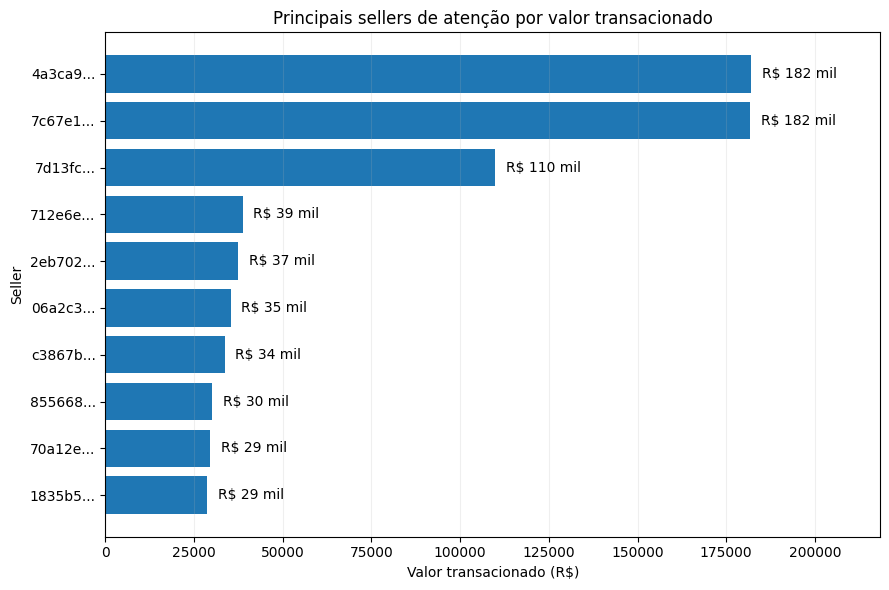

In [24]:
plt.figure(figsize=(9, 6))

barras = plt.barh(
    top_sellers['seller_curto'],
    top_sellers['valor_transacionado']
)

plt.title('Principais sellers de atenção por valor transacionado')
plt.xlabel('Valor transacionado (R$)')
plt.ylabel('Seller')

for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 3000,
        barra.get_y() + barra.get_height() / 2,
        f'R$ {valor / 1000:.0f} mil',
        va='center'
    )

plt.xlim(
    0,
    top_sellers['valor_transacionado'].max() * 1.20
)

plt.grid(axis='x', alpha=0.2)
plt.tight_layout()

plt.savefig(
    PASTA_GRAFICOS_EXECUTIVOS + '/07_priorizacao_sellers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura

Entre os **738 sellers** considerados na análise, foi identificado um grupo
de **22 sellers de atenção**, caracterizados pela combinação de maior
relevância financeira com taxas elevadas de atraso e avaliações baixas.

Esse grupo concentrou **6.710 pedidos** e aproximadamente **R$ 933 mil**
em valor transacionado, equivalente a cerca de **9,1% do valor analisado
entre os sellers considerados**.

O gráfico apresenta os dez sellers de atenção com maior valor transacionado,
com destaque para dois sellers que movimentaram aproximadamente
**R$ 182 mil cada** no período analisado.

A classificação não representa um ranking dos piores sellers, mas um critério
de priorização para investigação e acompanhamento operacional.

## 5. Recomendações executivas

Os resultados permitem direcionar as ações para os pontos que apresentaram
maior associação com a experiência dos clientes e maior relevância para
a operação.

### 5.1 Reduzir atrasos, principalmente os mais longos

O prazo de entrega foi o fator que apresentou a relação mais relevante
com a satisfação dos clientes.

A proporção de avaliações com nota 1 ou 2 passou de aproximadamente
**9% nos pedidos sem atraso para 62% nos pedidos atrasados**.

Nos atrasos entre 4 e 7 dias, aproximadamente **68%** dos pedidos já
receberam avaliações baixas, chegando a cerca de **80%** nos atrasos
superiores a 8 dias.

**Recomendação:** acompanhar a taxa e a quantidade de dias de atraso,
priorizando ações que evitem a evolução de atrasos pequenos para
atrasos mais longos.

### 5.2 Priorizar regiões considerando experiência e relevância

As taxas de atraso e insatisfação apresentam diferenças importantes
entre os estados.

O Rio de Janeiro se destacou no recorte analisado ao combinar alto volume
de pedidos com aproximadamente **11,9% de atraso** e **18,3% de avaliações
baixas**.

Além disso, cerca de **R$ 151 mil em valor transacionado** no estado
estiveram associados simultaneamente a atraso e avaliação baixa.

**Recomendação:** combinar volume, valor transacionado, atraso e satisfação
na definição das regiões prioritárias para investigação operacional.

### 5.3 Monitorar sellers de maior exposição

Foi identificado um grupo de **22 sellers de atenção**, responsável por
aproximadamente **R$ 933 mil em valor transacionado** e **6.710 pedidos**.

**Recomendação:** criar acompanhamento periódico desse grupo utilizando
indicadores de volume, atraso, avaliações baixas e valor transacionado,
permitindo direcionar investigações e ações de melhoria.

## 6. Mensagem final

A análise começou investigando se pedidos de maior valor estavam associados
a clientes mais satisfeitos.

Os dados não sustentaram essa hipótese.

O principal sinal identificado foi o desempenho da entrega:
pedidos atrasados apresentaram uma concentração muito maior de avaliações
negativas, e essa insatisfação se intensificou nos atrasos mais longos.

Além disso, o problema não se distribui igualmente pela operação.
Regiões e sellers apresentam diferentes níveis de exposição quando são
considerados conjuntamente volume, valor transacionado, atraso e satisfação.

### 6.1 Principal direcionamento

**O crescimento da operação deve ser acompanhado pela capacidade de manter
a qualidade da entrega.**

Para proteger a experiência do cliente em uma operação de maior escala,
a prioridade deve estar na redução de atrasos e no acompanhamento direcionado
das regiões e sellers de maior relevância operacional e financeira.

> **Crescer em volume é importante. Sustentar esse crescimento com uma
> experiência de entrega consistente é o principal ponto de atenção revelado
> pelos dados.**
